# Régression linéaire simple en Python

Ce notebook est une démonstration complète (explications + code) de la **régression linéaire simple** :
- charger un jeu de données réel (`income`, `happiness`)
- visualiser la relation
- poser la **problématique**
- estimer un modèle linéaire
- comprendre l’**optimisation** (ce que “minimiser l’erreur” veut dire)
- analyser les résidus
- évaluer la qualité du modèle (dont \(R^2\))
- faire de la **prédiction** (sur nouvelles données + sur un jeu de test)

**Variables**
- `income` : niveau de revenu (par 10 000 dollars)
- `happiness` : score de bonheur (0 à 10)


## 0) Importer les bibliothèques et charger les données

On utilise :
- **pandas** : lecture du fichier
- **numpy** : calculs
- **matplotlib** : graphiques

Le fichier est chargé depuis GitHub (lien `raw`).  
Si vous êtes hors-ligne, téléchargez le CSV et remplacez l’URL par un chemin local.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "Data/income.data.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()

Shape: (498, 3)


,Unnamed: 0,income,happiness
0,1,3.862647,2.314489
1,2,4.979381,3.433490
2,3,4.923957,4.599373
3,4,3.214372,2.791114
4,5,7.196409,5.596398


## 1) Poser la problématique

On veut **modéliser** la relation entre le revenu et le bonheur.

**Question :**  
> *Si je connais le revenu (`income`) d’un individu, puis-je estimer son niveau de bonheur (`happiness`) de manière raisonnable ?*

On cherche une relation simple, interprétable et facile à utiliser pour la prédiction.


## 2) Visualiser les données

Avant tout modèle, on observe si la relation semble avoir une tendance (à peu près) linéaire.


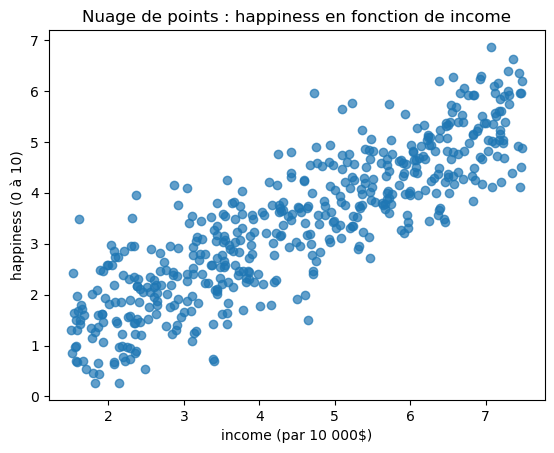

In [2]:
plt.scatter(df["income"], df["happiness"], alpha=0.7)
plt.xlabel("income (par 10 000$)")
plt.ylabel("happiness (0 à 10)")
plt.title("Nuage de points : happiness en fonction de income")
plt.show()

In [3]:
df.corr()

,Unnamed: 0,income,happiness
Unnamed: 0,1.000000,0.024831,0.029269
income,0.024831,1.000000,0.865634
happiness,0.029269,0.865634,1.000000


## 3) Le modèle linéaire

On utilise un modèle affine :

$
\widehat{happiness} = \beta_0 + \beta_1 \cdot income
$

- $(\beta_0$) : intercept (niveau “de base”)
- $(\beta_1$) : pente (variation moyenne de `happiness` quand `income` augmente d’une unité)

Le modèle fait une prédiction $(\hat{y}_i$) pour chaque observation $(i$).


## 4) Mesurer l’erreur : résidus et fonction de coût

Pour une observation $(i$) :
- valeur observée : $(y_i$)
- valeur prédite : $(\hat{y}_i$)

Le **résidu** (erreur point par point) :
$
\hat{\varepsilon}_i = y_i - \hat{y}_i
$

Pour entraîner un modèle, on a besoin d’une mesure globale de l’erreur.  
Un choix classique : **la somme des carrés des résidus** (ou sa version moyenne).

Fonction de coût (SSE) :
$
S(\beta_0,\beta_1)=\sum_{i=1}^n (y_i - (\beta_0+\beta_1 x_i))^2
$

**Objectif :**
$
(\hat{\beta}_0,\hat{\beta}_1)=\arg\min_{\beta_0,\beta_1} S(\beta_0,\beta_1)
$

👉 En clair : *on cherche les paramètres qui minimisent l’erreur totale*.


## 5) Optimisation : deux façons d’obtenir les coefficients

### A) Solution directe (M&thodes des moindres carrés ordirnaires (MCO)
Ici, la fonction de coût est convexe et l’optimum se calcule directement :

$
\hat{\beta}_1 = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2}
\quad ; \quad
\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}
$

### B) Optimisation itérative (descente de gradient)
On peut aussi minimiser la même fonction de coût en ajustant progressivement les paramètres :

1) on initialise $(\beta_0,\beta_1$)  
2) on calcule l’erreur  
3) on met à jour les paramètres dans la direction qui réduit le coût  
4) on répète (itérations)

Cette approche est la base de nombreux modèles plus complexes.


## 6) Estimer les coefficients (solution directe)

On applique les formules pour calculer $(\hat{\beta}_0$) et $(\hat{\beta}_1$).


In [4]:
x = df["income"]
y = df["happiness"]

x_bar = x.mean()
y_bar = y.mean()

beta1 = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar)**2)
beta0 = y_bar - beta1 * x_bar

print("beta0 =", beta0)
print("beta1 =", beta1)

beta0 = 0.20427039620417764
beta1 = 0.7138255122802073



$
\widehat{happiness} = 0,20 + 0.71 \cdot income
$

$
\widehat{happiness} = 0,20 + 0.71 *10=10,91
$

## 7) Estimer les coefficients (descente de gradient)

Même objectif (minimiser la somme des carrés), mais en mode itératif.

On minimise la MSE :
$
J(\beta_0,\beta_1) = \frac{1}{n}\sum (y_i - (\beta_0+\beta_1 x_i))^2
$

Mises à jour (schéma simple) :
$
\beta_0 \leftarrow \beta_0 - \eta \frac{\partial J}{\partial \beta_0}
\quad ; \quad
\beta_1 \leftarrow \beta_1 - \eta \frac{\partial J}{\partial \beta_1}
$

- $(\eta$) : taux d’apprentissage (hyperparamètre)
- plus $(\eta$) est grand, plus on avance vite… mais risque d’instabilité


In [5]:
def predict(x, b0, b1):
    return b0 + b1 * x

def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred)**2))

def fit_gd(x, y, lr=0.01, n_epochs=2000):
    b0 = 0.0
    b1 = 0.0
    n = len(x)
    history = []

    for epoch in range(n_epochs):
        y_hat = predict(x, b0, b1)
        error = y_hat - y

        # dérivées de la MSE
        db0 = (2/n) * np.sum(error)
        db1 = (2/n) * np.sum(error * x)

        b0 -= lr * db0
        b1 -= lr * db1

        if epoch % 50 == 0:
            history.append(mse(y, y_hat))

    return b0, b1, history

b0_gd, b1_gd, hist = fit_gd(x, y, lr=0.01, n_epochs=2000)

print("beta0 (GD) =", b0_gd)
print("beta1 (GD) =", b1_gd)

beta0 (GD) = 0.20387586371777863
beta1 (GD) = 0.7139026732091608


## 8) Comparer les deux estimations

Dans un problème aussi simple, la solution directe et la descente de gradient doivent donner des résultats proches (à un petit écart près).


Solution directe : 0.20427039620417764 0.7138255122802073
Descente gradient : 0.20387586371777863 0.7139026732091608


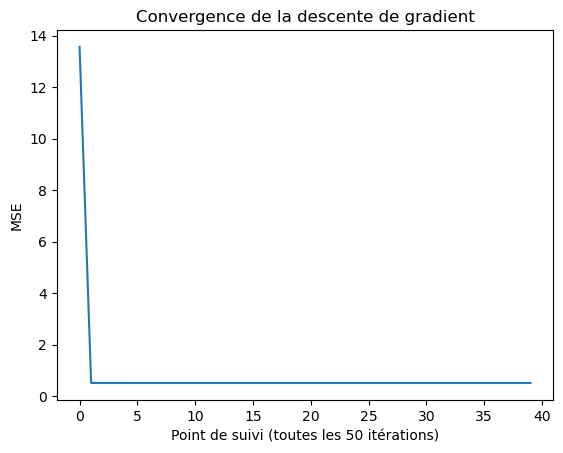

In [6]:
print("Solution directe :", beta0, beta1)
print("Descente gradient :", b0_gd, b1_gd)

plt.plot(hist)
plt.xlabel("Point de suivi (toutes les 50 itérations)")
plt.ylabel("MSE")
plt.title("Convergence de la descente de gradient")
plt.show()

## 9) Tracer la droite de régression

On visualise :
- les points observés
- la droite du modèle


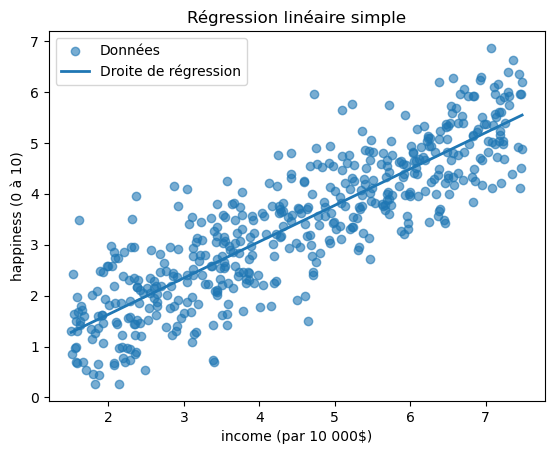

In [7]:
y_hat = beta0 + beta1 * x

x_line = np.linspace(x.min(), x.max(), 200)
y_line = beta0 + beta1 * x_line

plt.scatter(x, y, alpha=0.6, label="Données")
plt.plot(x_line, y_line, linewidth=2, label="Droite de régression")
plt.xlabel("income (par 10 000$)")
plt.ylabel("happiness (0 à 10)")
plt.title("Régression linéaire simple")
plt.legend()
plt.show()

## 10) Résidus : diagnostic visuel

Les résidus sont :
$
\hat{\varepsilon}_i = y_i - \hat{y}_i
$

On vérifie qu’ils sont globalement centrés autour de 0, sans structure évidente.


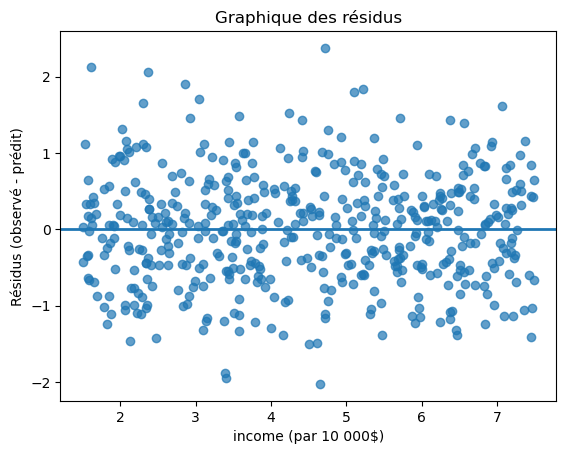

In [8]:
residuals = y - y_hat

plt.scatter(x, residuals, alpha=0.7)
plt.axhline(0, linewidth=2)
plt.xlabel("income (par 10 000$)")
plt.ylabel("Résidus (observé - prédit)")
plt.title("Graphique des résidus")
plt.show()

# Validation du modèle de régression linéaire

## 1. Linéarité
La relation entre la variable expliquée et les variables explicatives doit être linéaire.

**Outils de diagnostic :**
- Graphique de la variable expliquée en fonction des variables explicatives
- Graphique des résidus en fonction des variables explicatives
- Tests statistiques de spécification (ex. test de Ramsey RESET)



## 2. Homoscédasticité
La variance des erreurs doit être constante.

**Outils de diagnostic :**
- Test de Breusch–Pagan  
- Test de White  
- Graphique des résidus en fonction des valeurs prédites



## 3. Absence d’autocorrélation des erreurs
Les erreurs doivent être indépendantes les unes des autres.

**Remarque :**
- Cette hypothèse est généralement vérifiée lorsque les données ne sont pas temporelles.

**Outils de diagnostic (si données temporelles) :**
- Test de Durbin–Watson
- Test de Breusch–Godfrey


## 4. Nullité de l’espérance des erreurs
L’espérance conditionnelle des erreurs est nulle.

**Remarque :**
- Cette hypothèse est vérifiée par construction lorsque le modèle contient une constante.


## 5. Absence de multicolinéarité (régression multiple)
Les variables explicatives ne doivent pas être fortement corrélées entre elles.

**Outils de diagnostic :**
- Facteur d’inflation de la variance (VIF)

**Règle usuelle :**
- \( \text{VIF} < 5 \) : multicolinéarité faible  
- \( \text{VIF} \ge 5 \) : multicolinéarité problématique


## 6. Normalité des erreurs
Les erreurs doivent suivre une loi normale (hypothèse utile pour l’inférence).

**Outils de diagnostic :**
- Test de Shapiro–Wilk  
- Test de Kolmogorov–Smirnov  
- Test d’Anderson–Darling  
- Test de Jarque–Bera  
- QQ-plot des résidus


In [13]:
import numpy as np
import pandas as pd
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm


# Variables
x = df["income"]
y = df["happiness"]

# Moyennes
x_bar = x.mean()
y_bar = y.mean()

# Estimateurs MCO
beta1 = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar)**2)
beta0 = y_bar - beta1 * x_bar

print("beta0 =", beta0)
print("beta1 =", beta1)


# Valeurs ajustées et résidus
y_hat = beta0 + beta1 * x
residuals = y - y_hat


# Matrice des variables explicatives (avec constante)
X = sm.add_constant(x)

# Test de Breusch-Pagan
bp_test = het_breuschpagan(residuals, X)

bp_labels = [
    "Statistique LM",
    "p-value LM",
    "Statistique F",
    "p-value F"
]

dict(zip(bp_labels, bp_test))


beta0 = 0.20427039620417764
beta1 = 0.7138255122802073


{'Statistique LM': np.float64(1.3515216975291944),
 'p-value LM': np.float64(0.2450122676905909),
 'Statistique F': np.float64(1.349757003717672),
 'p-value F': np.float64(0.2458793530791694)}

## 11) Mesurer la qualité : $(R^2$)

$
R^2 = 1 - \frac{\sum (y_i-\hat{y}_i)^2}{\sum (y_i-\bar{y})^2}
$

- proche de 1 : le modèle explique une grande partie de la variance
- proche de 0 : le modèle explique peu


In [14]:
SCT = np.sum((y - y_bar)**2)
SCR = np.sum((y - y_hat)**2)
R2 = 1 - SCR / SCT
R2

np.float64(0.7493217544857413)

## 12) Prédiction : estimer `happiness` pour une nouvelle valeur de `income`

Une fois le modèle entraîné, on peut prédire sans avoir besoin de mesurer `happiness`.

Exemple : prédire le bonheur pour un revenu `income = 6.0` (soit 60 000$).


In [15]:
income_nouveau = 6.0
happiness_pred = beta0 + beta1 * income_nouveau
happiness_pred

np.float64(4.487223469885421)

## 13) Prédiction sur un jeu de test

Pour évaluer la capacité de généralisation :
- on apprend sur un **train**
- on prédit sur un **test**
- on compare les prédictions aux valeurs réelles


In [16]:
rng = np.random.default_rng(1234)

n = len(df)
test_idx = rng.choice(n, size=100, replace=False)
train_idx = np.setdiff1d(np.arange(n), test_idx)

train = df.iloc[train_idx]
test = df.iloc[test_idx]

x_train = train["income"].to_numpy()
y_train = train["happiness"].to_numpy()

xbar = x_train.mean()
ybar = y_train.mean()

b1 = np.sum((x_train - xbar) * (y_train - ybar)) / np.sum((x_train - xbar)**2)
b0 = ybar - b1 * xbar

x_test = test["income"].to_numpy()
y_test = test["happiness"].to_numpy()
y_pred = b0 + b1 * x_test

# erreurs sur test
mae_test = float(np.mean(np.abs(y_test - y_pred)))
mse_test = float(np.mean((y_test - y_pred)**2))

mae_test, mse_test

(0.57810219227204, 0.532584157318772)

## 14) Visualiser : observé vs prédit (bissectrice)

Si le modèle était parfait, tous les points seraient sur la ligne \(y = x\).


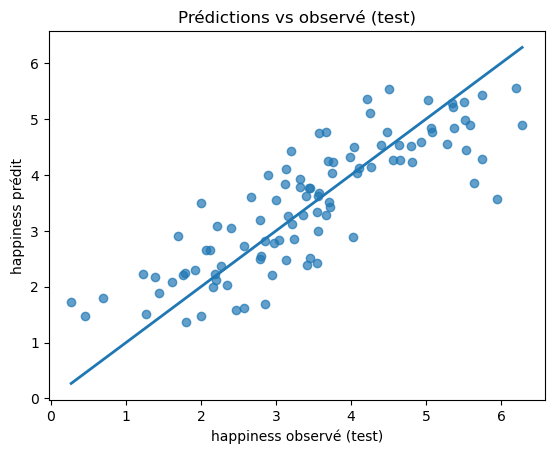

In [17]:
plt.scatter(y_test, y_pred, alpha=0.7)
minv = min(y_test.min(), y_pred.min())
maxv = max(y_test.max(), y_pred.max())
plt.plot([minv, maxv], [minv, maxv], linewidth=2)
plt.xlabel("happiness observé (test)")
plt.ylabel("happiness prédit")
plt.title("Prédictions vs observé (test)")
plt.show()

## 15) Visualiser les écarts sur `income` (segments)

On montre explicitement l’écart entre observé et prédit.


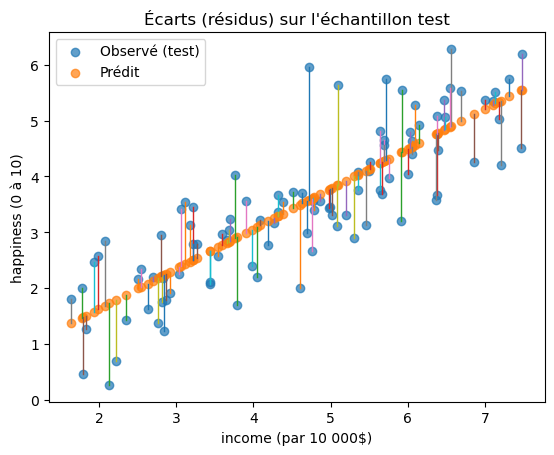

In [18]:
plt.scatter(test["income"], test["happiness"], label="Observé (test)", alpha=0.7)
plt.scatter(test["income"], y_pred, label="Prédit", alpha=0.7)

for xi, yi, ypi in zip(x_test, y_test, y_pred):
    plt.plot([xi, xi], [yi, ypi], linewidth=1)

plt.xlabel("income (par 10 000$)")
plt.ylabel("happiness (0 à 10)")
plt.title("Écarts (résidus) sur l'échantillon test")
plt.legend()
plt.show()

## 16) Résumé

Vous savez maintenant :
- poser une problématique de régression
- estimer un modèle linéaire simple
- comprendre ce que le modèle “optimise”
- diagnostiquer les résidus
- mesurer la qualité (dont \(R^2\))
- utiliser le modèle pour faire des prédictions (nouvelle valeur + test)

